# Malaga — Listings: Exploration & Cleaning
**Input :** `../../Data/raw/Malaga/listings.csv.gz`  
**Output:** `../../Data/interim/malaga_listings_clean.parquet`

Runs the shared `clean_listings()` pipeline, applies city-specific outlier
decisions, and exports a clean Parquet file consumed by the analysis notebook.

In [1]:
# !pip install pyarrow wordcloud textblob  # run once if needed

In [2]:
import sys
sys.path.insert(0, "../..")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import f_oneway, ttest_ind
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from airbnb_iip.data.cleaning import (
    clean_listings, missing_report,
    standardize_property_type, rate_bucket,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 80)
pd.set_option("display.max_colwidth", 200)

## 1 · Load raw data

In [3]:
l_df_raw = pd.read_csv(
    "../../Data/raw/Malaga/listings.csv.gz",
    compression="gzip",
    low_memory=False,
)
print(f"Shape  : {l_df_raw.shape}")
print(f"Memory : {l_df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Shape  : (9714, 79)
Memory : 42.9 MB


## 2 · Initial exploration

In [4]:
l_df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9714 entries, 0 to 9713
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            9714 non-null   int64  
 1   listing_url                                   9714 non-null   object 
 2   scrape_id                                     9714 non-null   int64  
 3   last_scraped                                  9714 non-null   object 
 4   source                                        9714 non-null   object 
 5   name                                          9714 non-null   object 
 6   description                                   9477 non-null   object 
 7   neighborhood_overview                         4170 non-null   object 
 8   picture_url                                   9714 non-null   object 
 9   host_id                                       9714 non-null   i

In [5]:
display(l_df_raw.head())
display(l_df_raw.tail())

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,96033,https://www.airbnb.com/rooms/96033,20250930030808,2025-09-30,city scrape,"Bonito piso a 200m de la playa, El Palo (Málaga)","Do you have a backpacker spirit and are looking for a nice, simple and affordable place in a popular neighborhood, with lots of life and very well connected? Book it!<br /><br />Nice 2 bedroom fla...","200 metres from the beaches of El Palo, Malaga's old fishing district. In front of the Carrefour Express supermarket, the bakery where you can also have breakfast if you feel like it, next to the ...",https://a0.muscache.com/pictures/hosting/Hosting-96033/original/f0554bc9-7a46-40df-b2f2-acf9b58c9806.jpeg,510467,https://www.airbnb.com/users/show/510467,Rafael,2011-04-15,"Andalusia, Spain","¡Hola! Gracias por acercarte a nosotros y encantados de saludarte. \r\nNos encanta hacer que la gente se sienta como en casa, ofrecerles una experiencia agradable y placentera para sus vacaciones ...",within an hour,100%,100%,t,https://a0.muscache.com/im/pictures/user/59fb2234-e2de-4ba7-9d07-5181a979a8a3.jpg?aki_policy=profile_small,https://a0.muscache.com/im/pictures/user/59fb2234-e2de-4ba7-9d07-5181a979a8a3.jpg?aki_policy=profile_x_medium,NaN,1,1,"['email', 'phone']",t,t,"Málaga, Andalusia, Spain",Este,NaN,36.720310,-4.356270,Entire rental unit,Entire home/apt,3,1.0,1 bath,2.0,2.0,"[""Kitchen"", ""Conditioner"", ""Heating"", ""Essentials"", ""Ethernet connection"", ""Wine glasses"", ""City skyline view"", ""Free street parking"", ""Shampoo"", ""Bed linens"", ""Beach essentials"", ""20 inch TV"", ""R...",$58.00,3,7,3.0,3.0,1125.0,1125.0,3.0,1125.0,NaN,t,6,36,62,324,2025-09-30,274,40,3,65,37,240,13920.0,2013-10-18,2025-09-29,4.61,4.70,4.62,4.88,4.93,4.44,4.61,ESFCTU0000290200003588210000000000000000VUT/MA/220430,f,1,1,0,0,1.88
1,166473,https://www.airbnb.com/rooms/166473,20250930030808,2025-09-30,city scrape,Perfect Location In Malaga,This apartment is rented out by the room - new kitchen and renovations carried out Oct 2020. Please confirm availability before making a booking. This is a 4 bedroom apartment one minute from the ...,NaN,https://a0.muscache.com/pictures/miso/Hosting-166473/original/61bc9e44-c8e4-4dec-a922-7df40db57288.jpeg,793360,https://www.airbnb.com/users/show/793360,Fred,2011-07-08,"El Faro, Spain","Hi All, my name is Fred and I am half Swedish and half English but live here in Spain full time. My company is based out of La Habana in Cuba www.cubaprofessionals.com My greatest love in life is ...",within a day,100%,88%,t,https://a0.muscache.com/im/pictures/user/f2d8a5e9-6448-46a5-ab98-3a3044ee3a12.jpg?aki_polic

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
9709,1518599566381530125,https://www.airbnb.com/rooms/1518599566381530125,20250930030808,2025-09-30,city scrape,Disfruta Málaga,This unique place has a style all its own.,NaN,https://a0.muscache.com/pictures/hosting/Hosting-1518599566381530125/original/100900c9-90e0-4d48-8b7c-3eb53df89d24.jpeg,2092252,https://www.airbnb.com/users/show/2092252,Juliette,2012-04-08,"Málaga, Spain","Me encanta sentirme útil y ayudar a los demás. \r\nSoy soñadora e idealista, entusiasta y emprendedora. Detallista y cuidadosa.\r\nAmante de la naturaleza y del arte sobre todo de la música, una d...",within a few hours,80%,45%,f,https://a0.muscache.com/im/pictures/user/User-2092252/original/77d2839a-e554-453b-a072-f53b71f7b367.jpeg?aki_policy=profile_small,https://a0.muscache.com/im/pictures/user/User-2092252/original/77d2839a-e554-453b-a072-f53b71f7b367.jpeg?aki_policy=profile_x_medium,El Atabal,15,29,"['email', 'phone']",t,t,NaN,Cruz De Humilladero,NaN,36.708016,-4.443965,Entire rental unit,Entire home/apt,3,1.0,1 bath,1.0,2.0,"[""Kitchen"", ""TV"", ""Air conditioning"", ""Exterior security cameras on property"", ""First aid kit"", ""Washer"", ""Wifi""]",$88.00,1,365,1.0,1.0,365.0,365.0,1.0,365.0,NaN,t,30,60,90,365,2025-09-30,0,0,0,93,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VFT/MA/10831,f,13,12,1,0,NaN
9710,1518757284222557214,https://www.airbnb.com/rooms/1518757284222557214,20250930030808,2025-09-30,city scrape,habitacion centro de malaga,Enjoy the simplicity of this quiet and central accommodation.,NaN,https://a0.muscache.com/pictures/hosting/Hosting-1518757284222557214/original/1d1b6fc5-666e-4767-b51f-535e974185ac.jpeg,422170051,https://www.airbnb.com/users/show/422170051,Karlene Andreina,2021-09-08,NaN,NaN,within an hour,80%,98%,f,https://a0.muscache.com/im/pictures/user/4f5aed0d-cd99-42fd-a85b-e3b4a8ff8477.jpg?aki_policy=profile_small,https://a0.muscache.com/im/pictures/user/4f5aed0d-cd99-42fd-a85b-e3b4a8ff8477.jpg?aki_policy=profile_x_medium,NaN,2,2,"['email', 'phone']",t,t,NaN,Centro,NaN,36.723280,-4.425650,Private room in rental unit,Private room,2,0.5,Shared half-bath,1.0,1.0,"[""Kitchen"", ""Bien shampoo"", ""Body soap"", ""Drying rack for clothing"", ""Bed linens"", ""Wifi"", ""Shower gel"", ""Bidet"", ""Hot water"", ""Hair dryer"", ""Outdoor shower""]",$26.00,1,365,1.0,1.0,365.0,365.0,1.0,365.0,NaN,t,19,49,79,351,2025-09-30,0,0,0,79,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Exempt,f,2,0,2,0,NaN
9711,1518872385705241311,https://www.airbnb.com/rooms/1518872385705241311,20250930030808,2025-09-30,city scrape,Casa Playa 3 Dormitorios,"Located in Málag

In [6]:
l_df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
id,9714.0,7.103469e+17,5.598955e+17,9.603300e+04,4.399760e+07,8.528307e+17,1.206495e+18,1.520070e+18
scrape_id,9714.0,2.025093e+13,0.000000e+00,2.025093e+13,2.025093e+13,2.025093e+13,2.025093e+13,2.025093e+13
host_id,9714.0,2.273979e+08,2.071479e+08,4.555300e+04,4.968590e+07,1.446971e+08,3.999613e+08,7.202991e+08
host_listings_count,9714.0,4.735948e+01,1.082701e+02,1.000000e+00,2.000000e+00,8.000000e+00,4.900000e+01,2.471000e+03
host_total_listings_count,9714.0,6.040220e+01,1.757007e+02,1.000000e+00,3.000000e+00,9.000000e+00,6.500000e+01,8.775000e+03
neighbourhood_group_cleansed,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,9714.0,3.672040e+01,1.334733e-02,3.664601e+01,3.671840e+01,3.672230e+01,3.672541e+01,3.688134e+01
longitude,9714.0,-4.420967e+00,2.447934e-02,-4.582370e+00,-4.428898e+00,-4.422651e+00,-4.417537e+00,-4.278520e+00
accommodates,9714.0,3.906424e+00,2.055744e+00,1.000000e+00,2.000000e+00,4.000000e+00,5.000000e+00,1.600000e+01
bathrooms,8815.0,1.277198e+00,6.676091e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.500000e+00,1.600000e+01


,missing_count,missing_percent
calendar_updated,9714,100.000000
neighbourhood_group_cleansed,9714,100.000000
host_neighbourhood,8468,87.173152
neighbourhood,5544,57.072267
neighborhood_overview,5544,57.072267
host_about,4174,42.968911
host_location,2280,23.471279
last_review,1005,10.345893
review_scores_rating,1005,10.345893
review_scores_accuracy,1005,10.345893


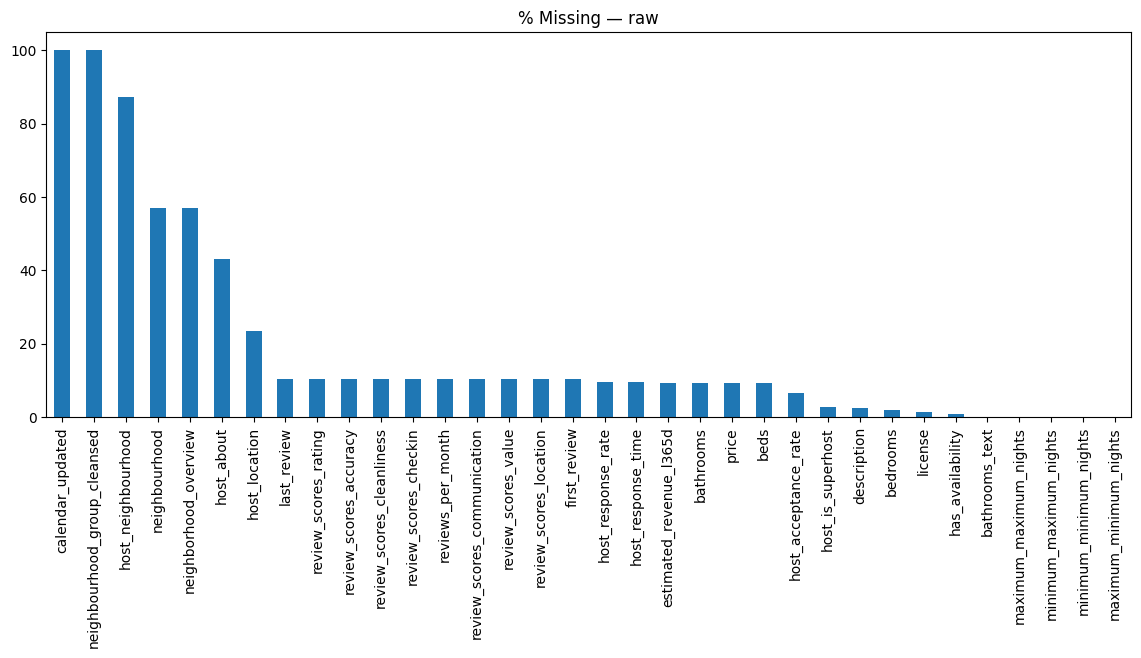

In [7]:
mr_raw = missing_report(l_df_raw)
mr_raw[mr_raw.missing_count > 0]["missing_percent"].plot(
    kind="bar", figsize=(14, 5), title="% Missing — raw"
)
display(mr_raw.head(20))

In [8]:
# Unique-value counts — categorical columns (skip long free-text)
_skip = {"description", "host_about", "neighborhood_overview", "amenities", "name"}
for col in l_df_raw.select_dtypes("object").columns.difference(_skip):
    print(f"\n{col}  ({l_df_raw[col].nunique()} unique)")
    print(l_df_raw[col].value_counts().head(6).to_string())


bathrooms_text  (30 unique)
bathrooms_text
1 bath            6191
2 baths           1687
1 shared bath      470
1.5 baths          350
1 private bath     295
0 baths            140

calendar_last_scraped  (1 unique)
calendar_last_scraped
2025-09-30    9714

first_review  (2696 unique)
first_review
2023-08-20    26
2024-08-18    25
2024-03-31    24
2023-04-09    21
2024-07-28    19
2025-04-20    19

has_availability  (1 unique)
has_availability
t    9626

host_acceptance_rate  (88 unique)
host_acceptance_rate
100%    4962
99%     1323
98%      573
97%      216
95%      175
0%       157

host_has_profile_pic  (2 unique)
host_has_profile_pic
t    9487
f     227

host_identity_verified  (2 unique)
host_identity_verified
t    9167
f     547

host_is_superhost  (2 unique)
host_is_superhost
f    6691
t    2758

host_location  (206 unique)
host_location
Málaga, Spain       4845
Andalusia, Spain    1233
Madrid, Spain        337
Malaga, Spain         97
Spain                 92
Andalucía, Spain

In [9]:
# Numeric ranges — flag obvious anomalies before cleaning
for col in l_df_raw.select_dtypes(include=["int64", "float64"]).columns:
    print(f"{col}: min={l_df_raw[col].min()}, max={l_df_raw[col].max()}")

id: min=96033, max=1520070219733116868
scrape_id: min=20250930030808, max=20250930030808
host_id: min=45553, max=720299095
host_listings_count: min=1, max=2471
host_total_listings_count: min=1, max=8775
neighbourhood_group_cleansed: min=nan, max=nan
latitude: min=36.6460124, max=36.8813362121582
longitude: min=-4.58237, max=-4.27852
accommodates: min=1, max=16
bathrooms: min=0.0, max=16.0
bedrooms: min=0.0, max=15.0
beds: min=0.0, max=25.0
minimum_nights: min=1, max=500
maximum_nights: min=1, max=1125
minimum_minimum_nights: min=1.0, max=500.0
maximum_minimum_nights: min=1.0, max=500.0
minimum_maximum_nights: min=1.0, max=1125.0
maximum_maximum_nights: min=1.0, max=1125.0
minimum_nights_avg_ntm: min=1.0, max=500.0
maximum_nights_avg_ntm: min=1.0, max=1125.0
calendar_updated: min=nan, max=nan
availability_30: min=0, max=30
availability_60: min=0, max=60
availability_90: min=0, max=90
availability_365: min=0, max=365
number_of_reviews: min=0, max=1110
number_of_reviews_ltm: min=0, max=21

In [10]:
# Duplicate check
print("Full duplicates           :", l_df_raw.duplicated().sum())
print("Duplicate listing ids     :", l_df_raw.duplicated(subset=['id']).sum())

# duplicated everything except the id 
# Count rows where everything matches except id
cols_except_id = l_df_raw.columns.difference(['id']).tolist()
dup_except_id_count = l_df_raw.duplicated(subset=cols_except_id).sum()
print("Duplicated except ids:", dup_except_id_count)    

# same name + host + coords - indicates host owns whole building. 
print("Duplicate (name+host+coords):",
      l_df_raw.duplicated(subset=['name','host_id','latitude','longitude']).sum())


Full duplicates           : 0
Duplicate listing ids     : 0
Duplicated except ids: 0
Duplicate (name+host+coords): 71


## 3 · Cleaning pipeline

`clean_listings()` handles (in order):
1. Drop `calendar_updated`, `neighbourhood` (always useless)
2. Deduplicate ignoring `id` / `listing_url`
3. Parse dates, prices, rates, booleans
4. Normalise multi-host name separators → `&`
5. Reconcile `bathrooms` / `bathrooms_text` (fixes the `fillna("mode")` bug from legacy code)
6. Hierarchical imputation — host fields → price → beds/bedrooms
7. Review-score zeros / sentinel dates for never-reviewed listings
8. Temporal features: `host_tenure_years`, `days_since_*`, `review_span_years`
9. Engineered features: `property_type_std`, rate categories, `price_cat` (city-adaptive quartiles), `description_length`
10. Drop URL / thumbnail columns

In [11]:
l_df = clean_listings(l_df_raw)
print(f"After clean_listings(): {l_df.shape}")
l_df.info()

After clean_listings(): (8762, 79)
<class 'pandas.core.frame.DataFrame'>
Index: 8762 entries, 0 to 9713
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   id                                            8762 non-null   int64         
 1   scrape_id                                     8762 non-null   int64         
 2   last_scraped                                  8762 non-null   datetime64[ns]
 3   source                                        8762 non-null   object        
 4   name                                          8762 non-null   object        
 5   description                                   8543 non-null   object        
 6   neighborhood_overview                         8762 non-null   object        
 7   picture_url                                   8762 non-null   object        
 8   host_id                               

### City-specific decisions

Document outlier thresholds and the EDA evidence that justifies them.

In [12]:
# Malaga-specific: extreme bed / bedroom counts found during EDA above
l_df = l_df[~((l_df['beds'] == 40) | (l_df['bedrooms'] == 25))]
print(f'After city-specific outlier removal: {l_df.shape}')

After city-specific outlier removal: (8762, 79)


,missing_count,missing_percent
neighbourhood_group_cleansed,8762,100.000000
days_since_first_review,867,9.895001
review_scores_communication,867,9.895001
review_scores_location,867,9.895001
review_scores_accuracy,867,9.895001
review_scores_value,867,9.895001
review_scores_rating,867,9.895001
review_scores_cleanliness,867,9.895001
review_scores_checkin,867,9.895001
days_since_last_review,867,9.895001


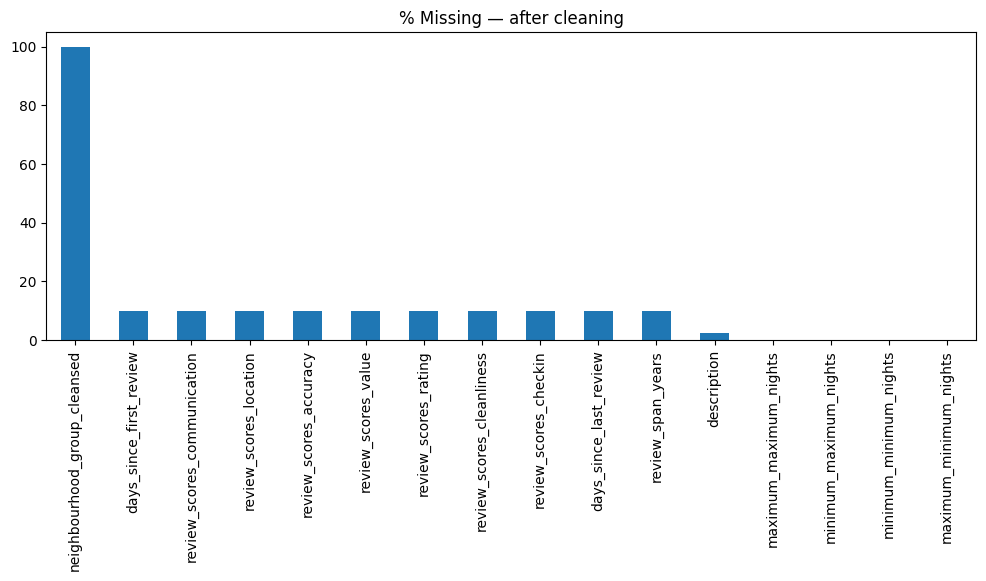

In [13]:
mr_clean = missing_report(l_df)
remaining = mr_clean[mr_clean.missing_count > 0]
if remaining.empty:
    print("No missing values remaining ✓")
else:
    display(remaining)
    remaining["missing_percent"].plot(
        kind="bar", figsize=(12, 4), title="% Missing — after cleaning"
    )

In [14]:
# Confirm final dtypes and feature set
l_df.info()
print("\nEngineered columns added:")
new_cols = set(l_df.columns) - set(l_df_raw.columns)
print(sorted(new_cols))

<class 'pandas.core.frame.DataFrame'>
Index: 8762 entries, 0 to 9713
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   id                                            8762 non-null   int64         
 1   scrape_id                                     8762 non-null   int64         
 2   last_scraped                                  8762 non-null   datetime64[ns]
 3   source                                        8762 non-null   object        
 4   name                                          8762 non-null   object        
 5   description                                   8543 non-null   object        
 6   neighborhood_overview                         8762 non-null   object        
 7   picture_url                                   8762 non-null   object        
 8   host_id                                       8762 non-null   int64      

## 4 · Export cleaned parquet

Output: `../../Data/interim/malaga_listings_clean.parquet`

In [15]:
import pathlib

out_path = pathlib.Path("../../Data/interim/malaga_listings_clean.parquet")
out_path.parent.mkdir(parents=True, exist_ok=True)

l_df.to_parquet(out_path, index=False, engine="pyarrow")

print(f"Saved {l_df.shape[0]:,} rows × {l_df.shape[1]} cols → {out_path}")
print(f"File size: {out_path.stat().st_size / 1e6:.1f} MB")

Saved 8,762 rows × 79 cols → ../../Data/interim/malaga_listings_clean.parquet
File size: 4.7 MB
